![logo](../../../.././docs/images/Logo_Destination_Earth_Colours.png)

## Time series at a single point with earthkit

This notebook shows how to extract an hourly time series from the Destination Earth Climate DT at a single location (Brussels) and visualise it with `earthkit.plots`.

**What you will learn**
- How to use Polytope's `timeseries` feature to retrieve hourly data efficiently at a single lat/lon
- How to compute monthly statistics with `earthkit.transforms`
- How to build multi-layer time series charts — lines, filled ranges, and multi-model overlays — using the `TimeSeries` class

## Setup

We import the four earthkit packages used in this notebook:

| Package | Alias | Purpose |
|---------|-------|---------|
| `earthkit.data` | `ekd` | Data access and I/O |
| `earthkit.plots` | `ekp` | Time series visualisation |
| `earthkit.geo` | `ekg` | Spatial utilities |
| `earthkit.transforms` | `ekt` | Temporal statistics |

We also import `TimeSeries` directly — the lower-level class that gives full control over chart layers.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.geo as ekg
import earthkit.transforms as ekt
from earthkit.plots.temporal import TimeSeries

### Define the target location

We pin the coordinates for Brussels once so both the Polytope request and any downstream labels stay consistent.

In [2]:
LOCATION = [50.85, 4.35]

### Retrieve an hourly time series from the Climate DT

Polytope's `timeseries` feature type does server-side extraction at a single point, so only the values for that location are transferred rather than a full global field for every time step. This makes retrieving a year of hourly data fast and lightweight.

**Key request fields**

| Field | Value | Meaning |
|-------|-------|---------|
| `activity` | `projections` | SSP scenario projections |
| `experiment` | `ssp3-7.0` | Middle-of-the-road high-emissions scenario |
| `model` | `ifs-nemo` | Coupled atmosphere–ocean model |
| `stream` | `clte` | Climate hourly time-step stream |
| `param` | `167` | 2 m temperature |
| `date` | `20400101/to/20401231` | Full year 2040 |
| `time` | `0000/to/2300` | All hours of the day |

The `feature` dictionary sets `type: timeseries` and passes the target coordinates. The `time_axis: date` option tells Polytope to organise the result along the date dimension.

In [3]:
ifs_nemo_request = {
    "activity": "projections",
    "class": "d1",
    "dataset": "climate-dt",
    "experiment": "ssp3-7.0",
    "generation": "2",
    "levtype": "sfc",
    "date": "20400101/to/20401231",
    "model": "ifs-nemo",
    "expver": "0001",
    "param": "167",
    "realization": "1",
    "resolution": "standard",
    "stream": "clte",
    "type": "fc",
    "time": "0000/to/2300",
    "feature": {
        "type" : "timeseries",
        "points": [[LOCATION[0], LOCATION[1]]],
        "time_axis": "date",
    }
}

ifs_nemo = ekd.from_source(
    "polytope",
    "destination-earth",
    ifs_nemo_request,
    address="polytope.mn5.apps.dte.destination-earth.eu",
    stream=False,
).to_xarray()

2026-06-09 17:53:17 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-06-09 17:53:17 - INFO - Sending request...
{'request': 'activity: projections\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20400101/to/20401231\n'
            'experiment: ssp3-7.0\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 50.85\n'
            '    - 4.35\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ifs-nemo\n'
            "param: '167'\n"
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-09 17:53:17 - INFO - Polytope user key found in session cache for user mavj
2026-06-09 17:53:18 - INFO - Request accepted. Please poll ./b6752685-415d-43d6-b4d6-98d1925c15fb for status


b6752685-415d-43d6-b4d6-98d1925c15fb.covjson:   0%|          | 0.00/374k [00:00<?, ?B/s]

### Inspect the Dataset

The result is an xarray Dataset with a single `t` time dimension covering all 8784 hourly time steps of 2040 (a leap year). The `latitude` and `longitude` coordinates reflect the nearest HEALPix cell centre to the requested point.

In [4]:
ifs_nemo

<xarray.Dataset> Size: 141kB
Dimensions:    (latitude: 1, longitude: 1, levelist: 1, number: 1, datetime: 1,
                t: 8784)
Coordinates:
  * latitude   (latitude) float64 8B 50.87
  * longitude  (longitude) float64 8B 4.714
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2040-12-31 00:00:00Z'
  * t          (t) datetime64[ns] 70kB 2040-01-01 ... 2040-12-31T23:00:00
Data variables:
    2t         (latitude, longitude, levelist, number, datetime, t) float64 70kB ...
Attributes: (12/14)
    activity:       projections
    class:          d1
    dataset:        climate-dt
    experiment:     ssp3-7.0
    expver:         0001
    generation:     2
    ...             ...
    realization:    1
    resolution:     standard
    stream:         clte
    type:           fc
    number:         0
    Forecast date:  2040-12-31 00:00:00Z

### Hourly line plot

The `TimeSeries` class is the lower-level API for building charts layer by layer. Here we plot the raw hourly series and group the x-axis ticks by month with `frequency="M"` and `period=True`. The title template uses `{model!u}` to uppercase the model name and `{location:%c}, {location:%C}` to format the city and country.

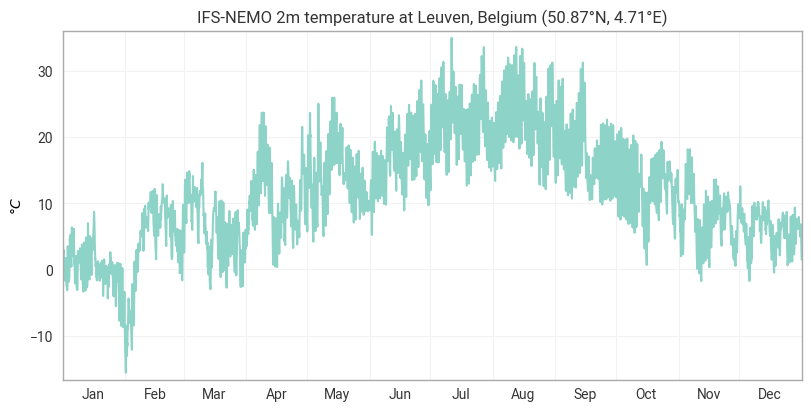

In [5]:
chart = TimeSeries()

chart.line(ifs_nemo, units="celsius")
chart.ylabel("{units}")
chart.title("{model!u} 2m temperature at {location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})")
chart.xticks(frequency="M", period=True)
chart.show()

### Monthly statistics

The hourly series is noisy at the annual scale. `earthkit.transforms` provides temporal aggregation functions that work directly on xarray Datasets. We compute three monthly statistics in one step:

- `monthly_mean` — the mean temperature for each calendar month
- `monthly_min` — the coldest hourly reading in each month
- `monthly_max` — the warmest hourly reading in each month

These will be used to draw a mean line overlaid on a shaded min–max range.

In [6]:
monthly_mean = ekt.temporal.monthly_mean(ifs_nemo)
monthly_min = ekt.temporal.monthly_min(ifs_nemo)
monthly_max = ekt.temporal.monthly_max(ifs_nemo)

### Monthly mean with min–max range

`chart.fill_between` shades the area between two datasets — here the monthly min and max — giving an immediate sense of intra-month variability. The mean line is drawn on top. `time_offset="15D"` shifts both layers to the middle of each month so the markers sit on the period they represent rather than at the start.

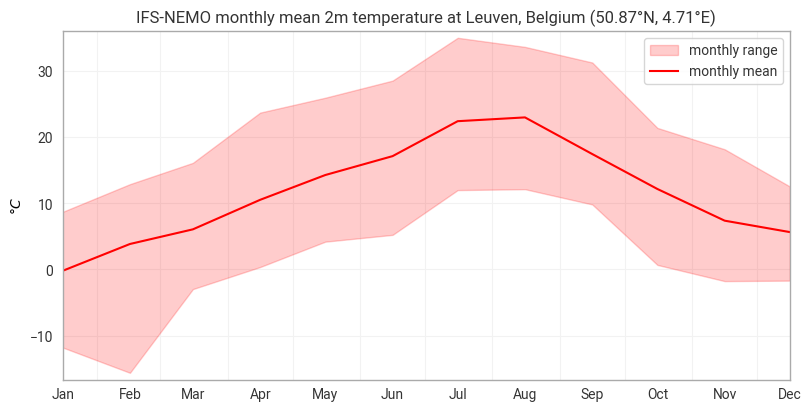

In [7]:
chart = TimeSeries()

chart.fill_between(monthly_min, monthly_max, color="red", label="monthly range", time_offset="15D", units="celsius")
chart.line(monthly_mean, color="red", time_offset="15D", label="monthly mean", units="celsius")
chart.ylabel("{units}")
chart.title("{model!u} monthly mean 2m temperature at {location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})")
chart.xticks(frequency="M", period=True)
chart.legend()
chart.show()

### Multi-model comparison

One of the strengths of the Climate DT is that multiple models ran the same scenario. We retrieve the same 2040 hourly series for **ICON** and **IFS-FESOM** by copying the original request dict and swapping the `model` key — all other fields stay identical.

Note that ICON and IFS-FESOM are served from the LUMI endpoint rather than MN5.

In [8]:
icon_request = ifs_nemo_request.copy()
icon_request["model"] = "icon"

icon = ekd.from_source(
    "polytope",
    "destination-earth",
    icon_request,
    address="polytope.lumi.apps.dte.destination-earth.eu",
    stream=False,
).to_xarray()

ifs_fesom_request = ifs_nemo_request.copy()
ifs_fesom_request["model"] = "ifs-fesom"

ifs_fesom = ekd.from_source(
    "polytope",
    "destination-earth",
    ifs_fesom_request,
    address="polytope.lumi.apps.dte.destination-earth.eu",
    stream=False,
).to_xarray()

2026-06-09 17:53:33 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-06-09 17:53:33 - INFO - Sending request...
{'request': 'activity: projections\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20400101/to/20401231\n'
            'experiment: ssp3-7.0\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 50.85\n'
            '    - 4.35\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: icon\n'
            "param: '167'\n"
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-09 17:53:33 - INFO - Polytope user key found in session cache for user mavj
2026-06-09 17:53:34 - INFO - Request accepted. Please poll ./f671e17f-4534-4076-b65c-563d0a9256d4 for status
2026

f671e17f-4534-4076-b65c-563d0a9256d4.covjson:   0%|          | 0.00/373k [00:00<?, ?B/s]

2026-06-09 17:53:46 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-06-09 17:53:46 - INFO - Sending request...
{'request': 'activity: projections\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20400101/to/20401231\n'
            'experiment: ssp3-7.0\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 50.85\n'
            '    - 4.35\n'
            '  time_axis: date\n'
            '  type: timeseries\n'
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '167'\n"
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0000/to/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-09 17:53:46 - INFO - Polytope user key found in session cache for user mavj
2026-06-09 17:53:46 - INFO - Request accepted. Please poll ./92a0c3a3-5f0d-4793-a4ef-c9ff04127c60 for status

92a0c3a3-5f0d-4793-a4ef-c9ff04127c60.covjson:   0%|          | 0.00/374k [00:00<?, ?B/s]

### Overlay all three models

We loop over the three datasets and call `chart.line` once per model, adding each as a separate layer on the same axes. `drawstyle="spline"` smooths the daily mean lines so the seasonal signal is easy to compare across models. The `{model!u}` label placeholder is resolved per-dataset, so the legend entries are named automatically.

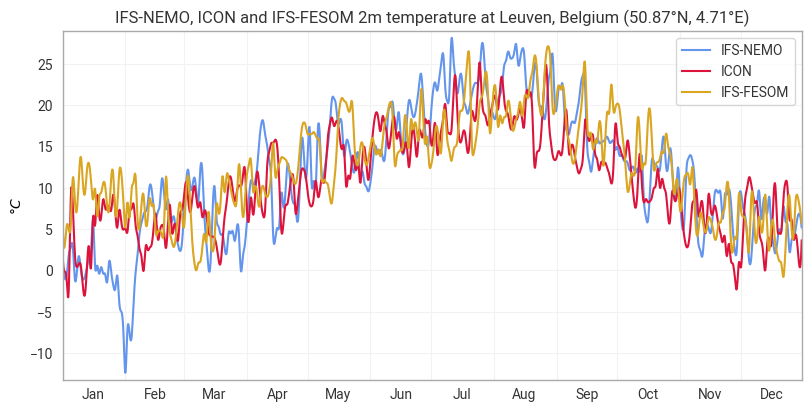

In [9]:
chart = TimeSeries()

COLORS = ["cornflowerblue", "crimson", "goldenrod"]
MODELS = [ifs_nemo, icon, ifs_fesom]

for color, data in zip(COLORS, MODELS):
    chart.line(
        ekt.temporal.daily_mean(data),
        label="{model!u}",
        color=color,
        units="celsius",
        drawstyle="spline",
    )

chart.ylabel("{units}")
chart.title("{model!u} 2m temperature at {location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})")
chart.xticks(frequency="M", period=True)
chart.legend()
chart.show()

---
## Summary

In this notebook you:
- Used Polytope's `timeseries` feature to retrieve a full year of hourly 2 m temperature at Brussels from three Climate DT models
- Computed monthly mean, min, and max with `earthkit.transforms`
- Built a multi-layer chart with a shaded min–max range and a mean line
- Overlaid daily-mean time series from IFS-NEMO, ICON, and IFS-FESOM to compare model behaviour

**Next steps:** Try a different location, variable, or year range — or extend the multi-model comparison to look at monthly climatologies rather than a single year.